# Multimodal Comparison of Deep Sleep and Propofol Anesthesia

## Data Audit & Initial Exploration

This notebook explores the initial structure and quality of multimodal neuroimaging data used for comparing natural unconsciousness (N3 sleep) and pharmacologically induced unconsciousness (propofol anesthesia).

The primary goals of this notebook are:

- load EEG and fMRI data
- inspect sleep stage annotations
- visualize raw signals
- verify dataset integrity
- perform initial quality control

## Imports

Importing core neuroimaging and data analysis libraries for EEG and fMRI inspection.

In [2]:
import mne
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt

from nilearn import plotting

## Loading N3 Sleep EEG Data

Loading BrainVision EEG recordings from the N3 sleep run selected after reviewing sleep stage annotations across subjects.

Subject `sub-23` was selected because it contained prolonged stable N3 sleep epochs.

In [4]:
raw = mne.io.read_raw_brainvision(
    "../data/raw/sleep_data/sub_23/eeg/sub-23_task-sleep_run-3_eeg.vhdr",
    preload=True
)

raw

Extracting parameters from ../data/raw/sleep_data/sub_23/eeg/sub-23_task-sleep_run-3_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 4601199  =      0.000 ...   920.240 secs...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8104\3233538151.py:1: RuntimeWarning: Channels contain different highpass filters. Lowest (weakest) filter setting (0.00 Hz) will be stored.
  raw = mne.io.read_raw_brainvision(


<RawBrainVision | sub-23_task-sleep_run-3_eeg.eeg, 32 x 4601200 (920.2 s), ~1.10 GiB, data loaded>

In [23]:
raw.ch_names

['Fp1',
 'Fp2',
 'F3',
 'F4',
 'C3',
 'C4',
 'P3',
 'P4',
 'O1',
 'O2',
 'F7',
 'F8',
 'T7',
 'T8',
 'P7',
 'P8',
 'Fz',
 'Cz',
 'Pz',
 'Oz',
 'FC1',
 'FC2',
 'CP1',
 'CP2',
 'FC5',
 'FC6',
 'CP5',
 'CP6',
 'TP9',
 'TP10',
 'EOG',
 'ECG']

In [21]:
raw.set_channel_types(
    {ch: "eeg" for ch in raw.ch_names}
)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8104\1125738844.py:1: RuntimeWarning: The unit for channel(s) C3, C4, CP1, CP2, CP5, CP6, Cz, ECG, EOG, F3, F4, F7, F8, FC1, FC2, FC5, FC6, Fp1, Fp2, Fz, O1, O2, Oz, P3, P4, P7, P8, Pz, T7, T8, TP10, TP9 has changed from NA to V.
  raw.set_channel_types(


<RawBrainVision | sub-23_task-sleep_run-3_eeg.eeg, 32 x 4601200 (920.2 s), ~1.10 GiB, data loaded>

## EEG Signal Inspection

Visual inspection of raw EEG activity to identify expected slow-wave sleep characteristics and verify recording quality.

Using matplotlib as 2D backend.


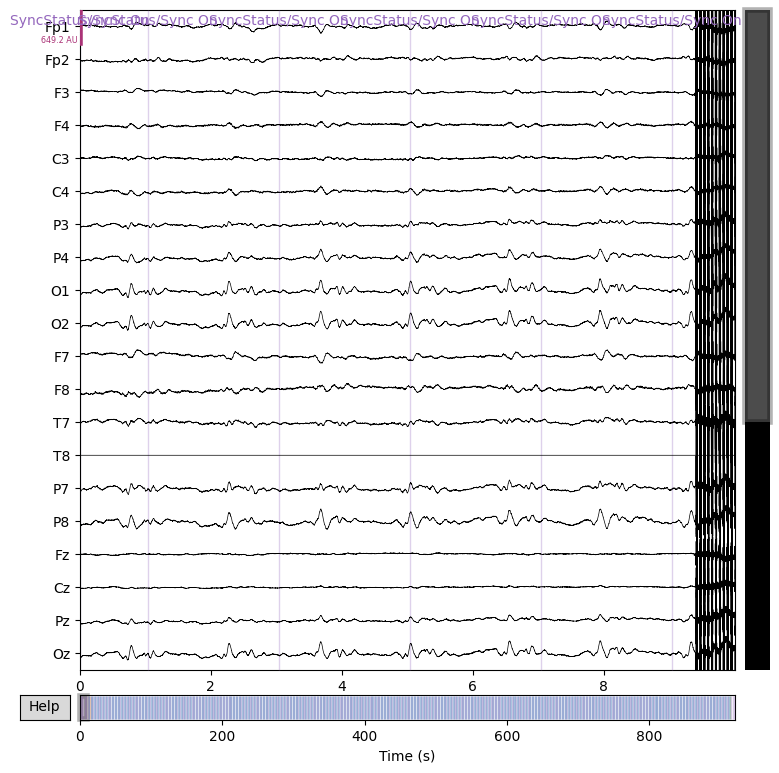

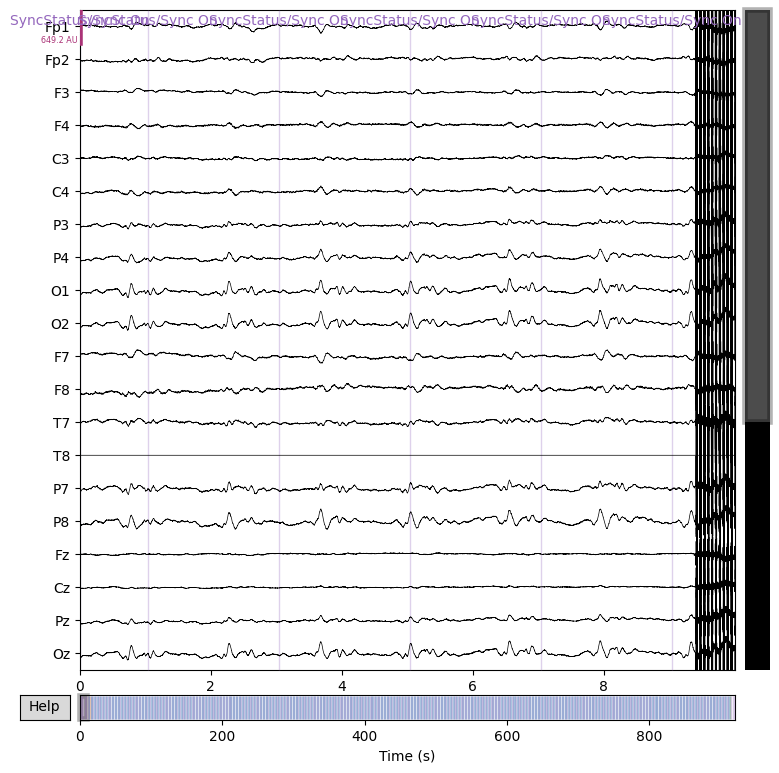

In [5]:
raw.plot()

## Power Spectral Density (PSD)

Inspecting the frequency composition of the EEG signal.

Deep sleep is expected to show increased low-frequency (delta-band) activity.

Effective window size : 0.410 (s)
Plotting power spectral density (dB=True).


C:\Users\Lenovo\Desktop\data_prjcts\different-paths-to-unresponsiveness\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


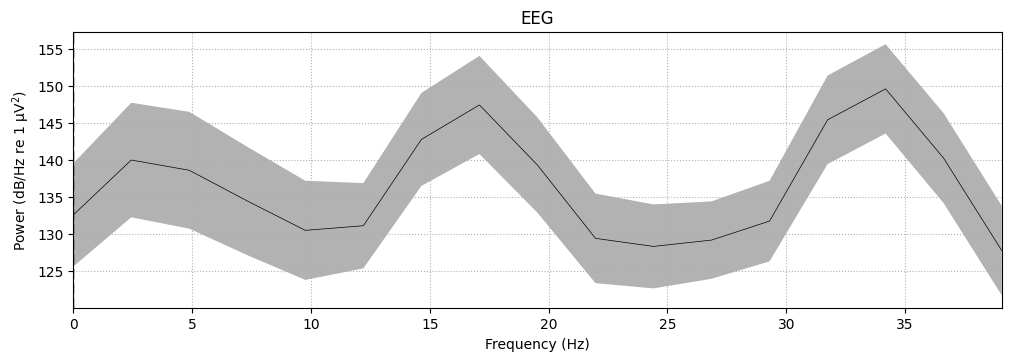

In [22]:
raw.compute_psd(fmax=40).plot(
    average=True
)

## Sleep Stage Annotations

Loading manually scored sleep stage labels for the selected subject.

Sleep stages are organized into 30-second epochs:
- W = wakefulness
- 1 = N1
- 2 = N2
- 3 = N3 (deep sleep)

In [6]:
sleep_stages = pd.read_csv(
    "../data/raw/sleep_data/sub_23/sub-23-sleep-stage.tsv",
    sep="\t"
)

sleep_stages.head()

,session,epoch_start_time_sec,30-sec_epoch_sleep_stage
0,task-rest_run-1,0,W (uncertain)
1,task-rest_run-1,30,W (uncertain)
2,task-rest_run-1,60,W (uncertain)
3,task-rest_run-1,90,W (uncertain)
4,task-rest_run-1,120,W (uncertain)


## Identifying N3 Epochs

Filtering epochs corresponding to N3 sleep for further multimodal analysis.

In [7]:
sleep_stages[
    sleep_stages["30-sec_epoch_sleep_stage"].astype(str).str.contains("3")
]

,session,epoch_start_time_sec,30-sec_epoch_sleep_stage
86,task-sleep_run-2,480,2 or 3 (unscorable)
87,task-sleep_run-2,510,2 or 3 (unscorable)
88,task-sleep_run-2,540,2 or 3 (unscorable)
89,task-sleep_run-2,570,3 (unscorable)
90,task-sleep_run-2,600,3 (unscorable)
91,task-sleep_run-2,630,3 (unscorable)
92,task-sleep_run-2,660,3 (unscorable)
93,task-sleep_run-2,690,3 (unscorable)
94,task-sleep_run-2,720,3 (unscorable)
95,task-sleep_run-2,750,3 (unscorable)


## Loading Sleep fMRI Data

Loading 4D BOLD fMRI data corresponding to the N3 sleep run.

fMRI datasets contain volumetric brain activity measured across time:
- x
- y
- z
- time

In [8]:
sleep_img = nib.load(
    "../data/raw/sleep_data/sub_23/fmri/sub-23_task-sleep_run-3_bold.nii.gz"
)

sleep_img.shape

(80, 80, 35, 429)

## Visualizing Sleep fMRI

Displaying a representative brain volume from the N3 sleep recording for initial quality inspection.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8104\391095648.py:3: UserWarning: Casting data from int32 to float32
  plotting.plot_epi(


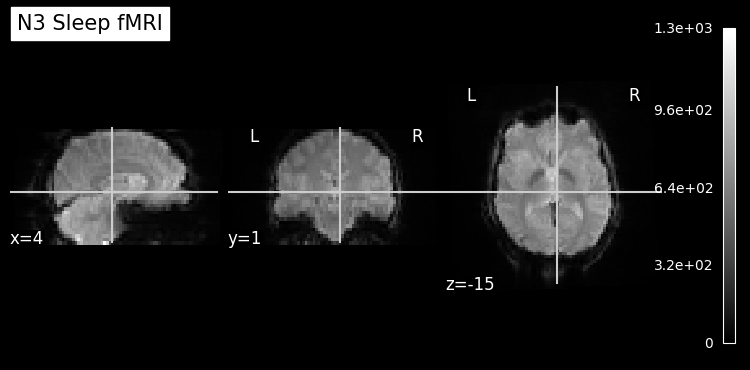

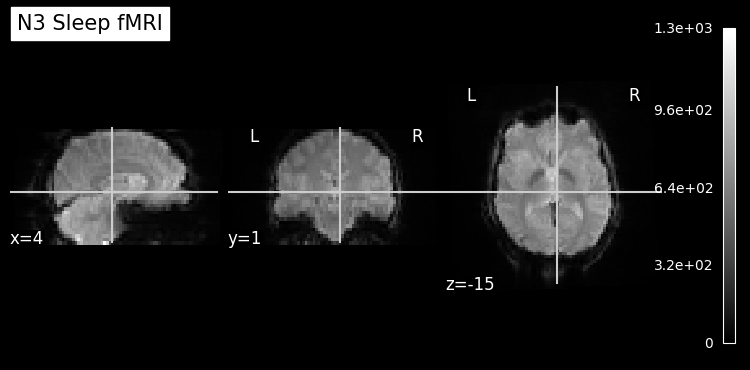

In [11]:
sleep_img_3d = sleep_img.slicer[:, :, :, 0]

plotting.plot_epi(
    sleep_img_3d,
    title="N3 Sleep fMRI"
)

plt.show()

## Loading Propofol fMRI Data

Loading resting-state fMRI data acquired under propofol anesthesia.

This dataset will later be compared against deep NREM sleep dynamics.

In [12]:
propofol_img = nib.load(
    "../data/raw/propofol_data/sub-02_task-rest_run-1_bold.nii.gz"
)

propofol_img.shape

(64, 64, 21, 770)

## Visualizing Propofol fMRI

Initial visualization of propofol fMRI data.

The propofol dataset appears lower in spatial quality and contrast relative to the sleep dataset, likely reflecting differences in acquisition protocols and scanner parameters across studies.

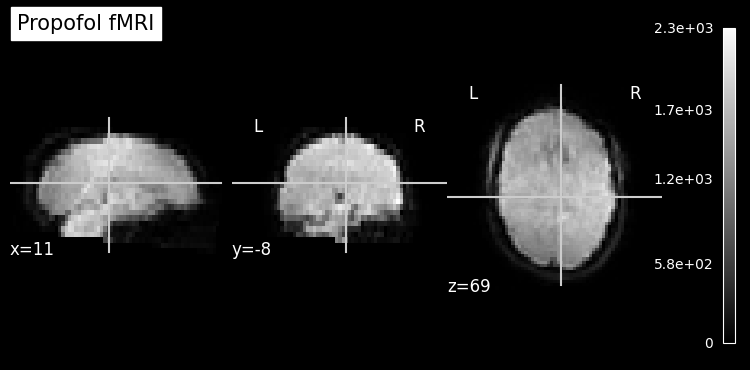

In [15]:
propofol_img_3d = propofol_img.slicer[:, :, :, 0]

plotting.plot_epi(
    propofol_img_3d,
    title="Propofol fMRI"
)

plt.show()

## Preliminary Observations

Key observations from the initial audit:

- Stable N3 sleep epochs were identified in subject `sub-23`
- EEG recordings loaded successfully and showed expected slow-wave structure
- Both sleep and propofol fMRI datasets were successfully loaded
- The propofol dataset appears noisier and lower-resolution compared to the sleep dataset
- Additional preprocessing and normalization steps will likely be necessary before direct comparisons